In [7]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

### Generate data

In [14]:
X_train = np.linspace(-1,1,20)

y_train = np.array([-0.6561 , -0.3099 , -0.59035, -0.50855, -0.285  , 
                    -0.2443 , -0.02445,  0.00135, -0.2006 ,  0.07475, 
                    -0.1422 ,  0.06515,  0.15265,  0.3521 ,  0.28415,  
                    0.5524 ,  0.23115,  0.20835, 0.4211,  0.60485])

X_test = np.linspace(-1,1,20)

y_test = np.array([-0.69415, -0.451  , -0.43005, -0.4484 , -0.1475 ,
                   -0.5019 , -0.28055,  0.24595, -0.21425, -0.0286 ,  
                   0.23415,  0.46575, 0.07955,  0.1973 ,  0.0719 ,
                   0.3639 ,  0.5536 ,  0.3365 , 0.50705,  0.33435])



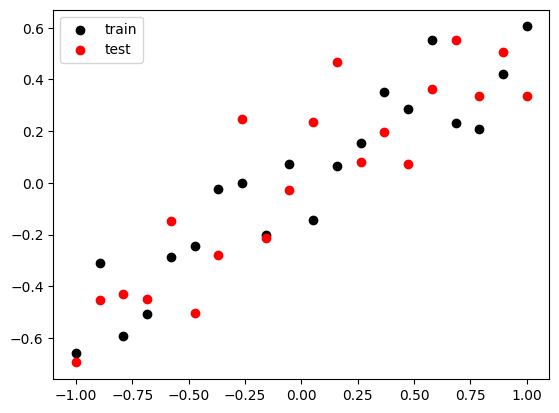

In [15]:
plt.scatter(X_train,y_train,c='black',label='train')
plt.scatter(X_test,y_test,c='red',label='test')
plt.legend()
plt.show()

### Regression Model

In [17]:
model  = Sequential()

model.add(Dense(128, activation="relu",input_dim = 1))
model.add(Dense(128, activation="relu"))
model.add(Dense(1, activation="linear"))
adam = Adam(learning_rate=0.01)
model.compile(loss='mean_squared_error',optimizer=adam,metrics=['mse'])
history = model.fit(X_train,y_train,epochs=500,validation_data=(X_test,y_test),verbose=False)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Evaluate the model

In [18]:
_, train_mse = model.evaluate(X_train,y_train,verbose=0)
_, test_mse = model.evaluate(X_test,y_test,verbose=0)
print("Train",train_mse)
print("Train",test_mse)

Train 0.004792640917003155
Train 0.045192670077085495


In [19]:
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step


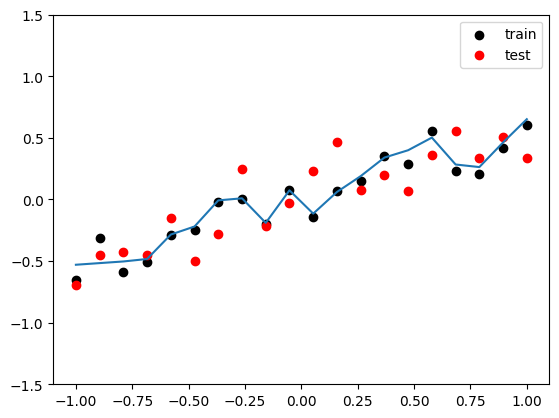

In [21]:
plt.figure()
plt.scatter(X_train,y_train,c='black',label='train')
plt.scatter(X_test,y_test,c='red',label='test')
plt.plot(X_test,y_pred)
plt.legend()
plt.ylim((-1.5,
          1.5))
plt.show()

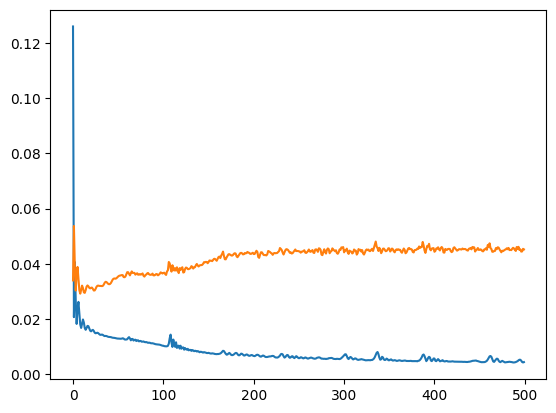

In [22]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

### DropOut Model

In [23]:
model1  = Sequential()

model1.add(Dense(128, activation="relu",input_dim = 1))
model1.add(Dropout(0.2))
model1.add(Dense(128, activation="relu"))
model1.add(Dropout(0.2))
model1.add(Dense(1, activation="linear"))
adam = Adam(learning_rate=0.01)
model1.compile(loss='mean_squared_error',optimizer=adam,metrics=['mse'])
history = model1.fit(X_train,y_train,epochs=500,validation_data=(X_test,y_test),verbose=False)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
_, train_mse = model1.evaluate(X_train,y_train,verbose=0)
_, test_mse = model1.evaluate(X_test,y_test,verbose=0)
print("Train",train_mse)
print("Train",test_mse)

Train 0.010412706062197685
Train 0.04015941172838211


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


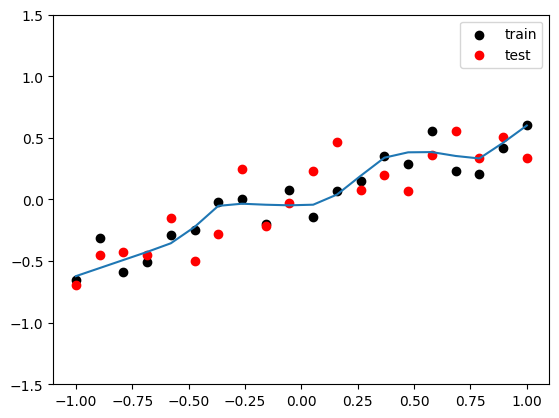

In [27]:
y_pred1 = model1.predict(X_test)
plt.figure()
plt.scatter(X_train,y_train,c='black',label='train')
plt.scatter(X_test,y_test,c='red',label='test')
plt.plot(X_test,y_pred1)
plt.legend()
plt.ylim((-1.5,
          1.5))
plt.show()

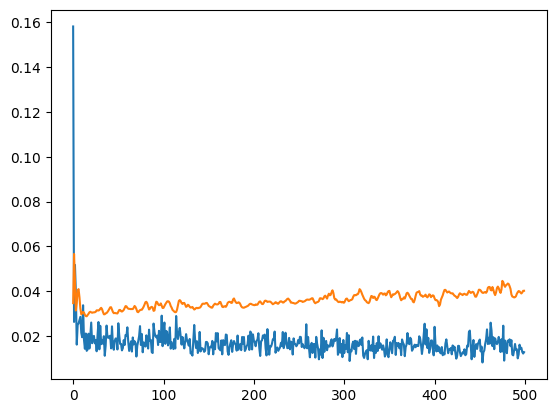

In [28]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])